In [ ]:
#1Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

In [ ]:
#2Loading Dataset
df = pd.read_csv("C:/Users/yashr/Desktop/eve6/google_play_store_dataset.csv")

print(df.shape)
df.head()


(10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [21]:
print(df.columns.tolist())

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [22]:
#Removing duplicates
df = df.drop_duplicates(subset='App')

print(df.shape)

(9660, 13)


In [23]:
#Cleaning installs
df['Installs'] = (
    df['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

df['Installs'] = pd.to_numeric(
    df['Installs'],
    errors='coerce'
)

In [24]:
#Cleaning price
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
)

df['Price'] = pd.to_numeric(
    df['Price'],
    errors='coerce'
)

In [25]:
#Creating Revenue Columns
df['Revenue'] = df['Price'] * df['Installs']

In [26]:
#Cleaning size 
df = df[df['Size'].astype(str).str.contains('M', na=False)]

df['Size_MB'] = (
    df['Size']
    .astype(str)
    .str.replace('M', '', regex=False)
)

df['Size_MB'] = pd.to_numeric(
    df['Size_MB'],
    errors='coerce'
)

In [27]:
#Cleaning Android versions
df['Android_Version_Num'] = (
    df['Android Ver']
    .astype(str)
    .str.extract(r'(\d+\.\d+)')
)

df['Android_Version_Num'] = pd.to_numeric(
    df['Android_Version_Num'],
    errors='coerce'
)

In [28]:
#Calculating app name by length
df['App_Length'] = (
    df['App']
    .astype(str)
    .str.len()
)

In [29]:
#Applying all filters
filtered_df = df[
    (df['Installs'] >= 10000) &
    (df['Revenue'] >= 10000) &
    (df['Android_Version_Num'] > 4.0) &
    (df['Size_MB'] > 15) &
    (df['Content Rating'] == 'Everyone') &
    (df['App_Length'] <= 30)
].copy()

print("Filtered Records:", len(filtered_df))

Filtered Records: 28


In [30]:
#Top 3 Categories
top_categories = (
    filtered_df['Category']
    .value_counts()
    .head(3)
)

print(top_categories)

Category
GAME         7
FAMILY       6
EDUCATION    2
Name: count, dtype: int64


In [31]:
top_3 = top_categories.index.tolist()

filtered_df = filtered_df[
    filtered_df['Category'].isin(top_3)
]

In [32]:
#Aggregating data
summary = (
    filtered_df
    .groupby(['Category', 'Type'])
    .agg({
        'Installs':'mean',
        'Revenue':'mean'
    })
    .reset_index()
)

summary

,Category,Type,Installs,Revenue
0,EDUCATION,Paid,300000.000000,1.197000e+06
1,FAMILY,Paid,361666.666667,5.972167e+05
2,GAME,Paid,67142.857143,2.764714e+05


Unique Types Found:
['Paid']


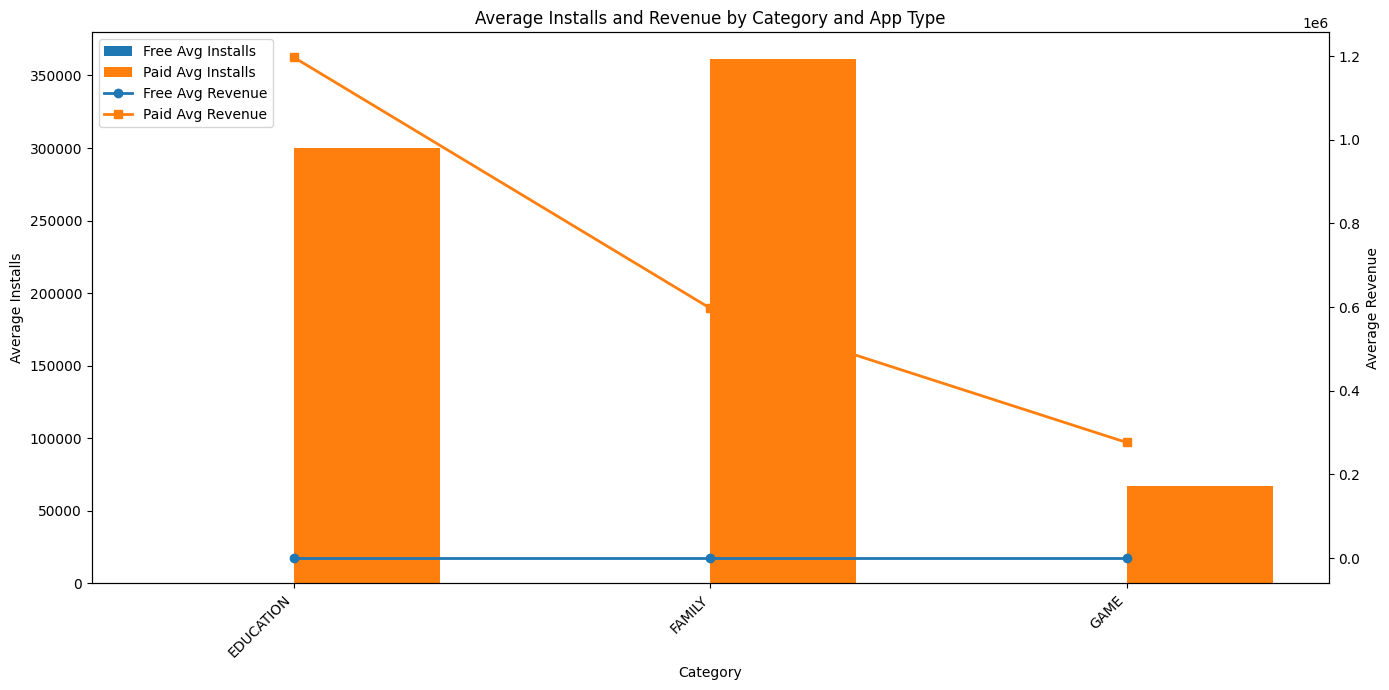


Pivot Installs
Type                Paid  Free
Category                      
EDUCATION  300000.000000     0
FAMILY     361666.666667     0
GAME        67142.857143     0

Pivot Revenue
Type               Paid  Free
Category                     
EDUCATION  1.197000e+06     0
FAMILY     5.972167e+05     0
GAME       2.764714e+05     0

Type Counts
Type
Paid    15
Name: count, dtype: int64


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================
# Create Summary Tables
# ==================================

summary = (
    filtered_df
    .groupby(['Category', 'Type'])
    .agg({
        'Installs': 'mean',
        'Revenue': 'mean'
    })
    .reset_index()
)

print("Unique Types Found:")
print(summary['Type'].unique())

# ==================================
# Create Pivot Tables
# ==================================

pivot_installs = summary.pivot(
    index='Category',
    columns='Type',
    values='Installs'
).fillna(0)

pivot_revenue = summary.pivot(
    index='Category',
    columns='Type',
    values='Revenue'
).fillna(0)

# ==================================
# Add Missing Columns if Needed
# ==================================

for col in ['Free', 'Paid']:
    if col not in pivot_installs.columns:
        pivot_installs[col] = 0

    if col not in pivot_revenue.columns:
        pivot_revenue[col] = 0

# Keep same category order
pivot_revenue = pivot_revenue.reindex(pivot_installs.index)

# ==================================
# Data for Plotting
# ==================================

free_installs = pivot_installs['Free'].values
paid_installs = pivot_installs['Paid'].values

free_revenue = pivot_revenue['Free'].values
paid_revenue = pivot_revenue['Paid'].values

categories = pivot_installs.index.tolist()

# ==================================
# Plot
# ==================================

x = np.arange(len(categories))
width = 0.35

fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

# Bars
ax1.bar(
    x - width/2,
    free_installs,
    width,
    label='Free Avg Installs'
)

ax1.bar(
    x + width/2,
    paid_installs,
    width,
    label='Paid Avg Installs'
)

# Lines
ax2.plot(
    x,
    free_revenue,
    marker='o',
    linewidth=2,
    label='Free Avg Revenue'
)

ax2.plot(
    x,
    paid_revenue,
    marker='s',
    linewidth=2,
    label='Paid Avg Revenue'
)

# Labels
ax1.set_xlabel('Category')
ax1.set_ylabel('Average Installs')
ax2.set_ylabel('Average Revenue')

ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=45, ha='right')

ax1.set_title(
    'Average Installs and Revenue by Category and App Type'
)

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left'
)

plt.tight_layout()
plt.show()

# ==================================
# Debug Information
# ==================================

print("\nPivot Installs")
print(pivot_installs)

print("\nPivot Revenue")
print(pivot_revenue)

print("\nType Counts")
print(filtered_df['Type'].value_counts())